In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

In [247]:
np.random.seed(42)
mean = [2.8, 2.7]
cov = [[2.0, 1.2],
       [1.2, 1.5]]
X_train = np.random.multivariate_normal(mean, cov, 200)


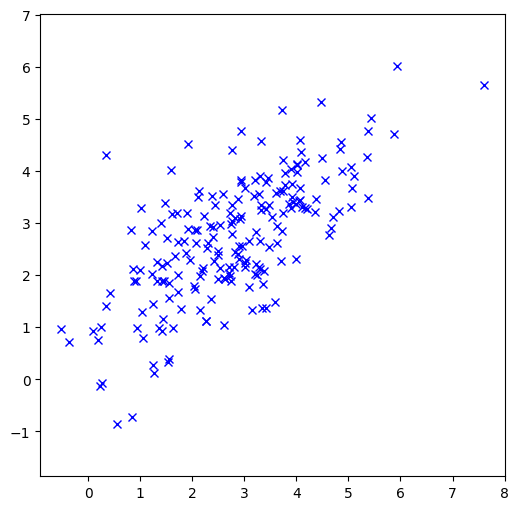

In [248]:
plt.figure(figsize=(6,6))
plt.plot(X_train[:,0], X_train[:,1], 'bx')
plt.axis('equal')
plt.show()

In [249]:
# Quan sát ta thấy dữ liệu không phân cụm rõ ràng
# Sử dụng KMeans trước

In [250]:
# Tìm k với silhouette score

k = 2, silhouette = 0.4404
k = 3, silhouette = 0.3887
k = 4, silhouette = 0.3564
k = 5, silhouette = 0.3711
k = 6, silhouette = 0.3694
k = 7, silhouette = 0.3412
Best k = 2


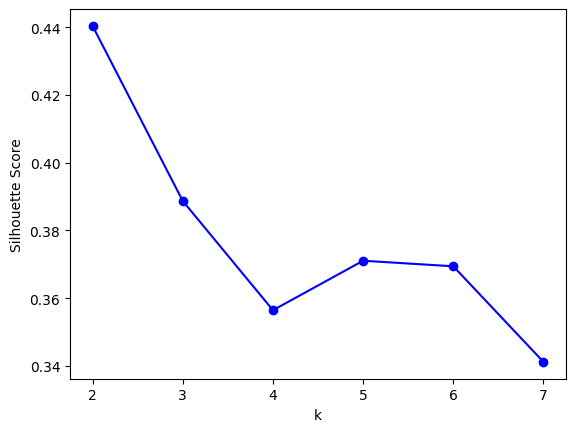

In [251]:
from sklearn.metrics import silhouette_score

scores = []
K = range(2, 8)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42)
    kmeanModel.fit(X_train)
    score = silhouette_score(X_train, kmeanModel.labels_)
    scores.append(score)

# In từng score
for k, s in zip(K, scores):
    print(f"k = {k}, silhouette = {s:.4f}")

# k tốt nhất
id_max = np.argmax(scores)
print("Best k =", K[id_max])

# Vẽ biểu đồ
plt.plot(K, scores, 'bo-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.show()

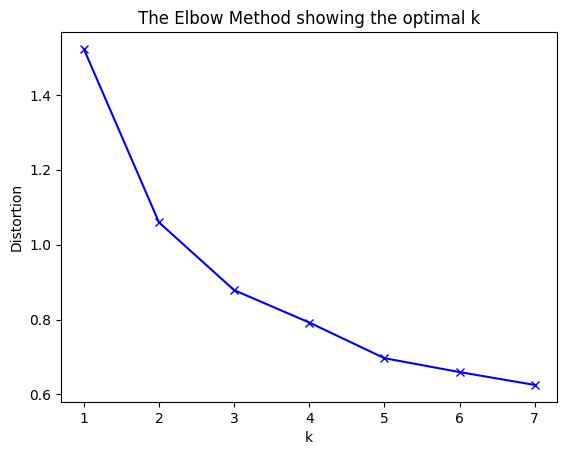

In [252]:
from scipy.spatial.distance import cdist
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

distortions = []
K = range(1,8)

for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(X_train)
    distortions.append(sum(np.min(cdist(X_train, kmeanModel.cluster_centers_, 'euclidean'), axis=1)) / X_train.shape[0])

# Plot the elbow
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.show()

In [253]:
# Thực hiện KMeans với k=2
from sklearn.cluster import KMeans

kmeanModel = KMeans(n_clusters=2)
kmeanModel.fit(X_train)
centroids = kmeanModel.cluster_centers_
labels = kmeanModel.labels_

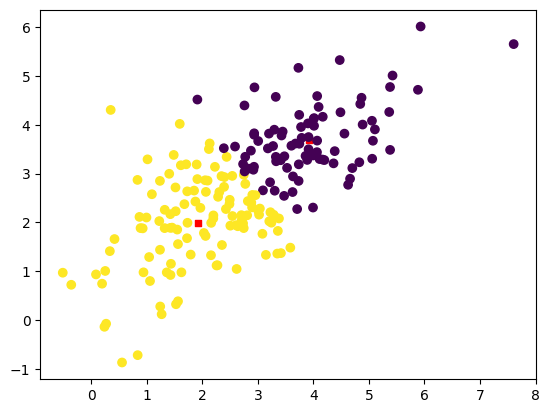

In [254]:
# ----- Visualize kết quả
import pandas as pd
import matplotlib.pyplot as plt

df_group = pd.Series(labels)
plt.scatter(centroids[:, 0], centroids[:, 1], marker="s", s=15, color='red')
plt.scatter(X_train[:, 0], X_train[:, 1], c=df_group)
plt.show()

##GMM


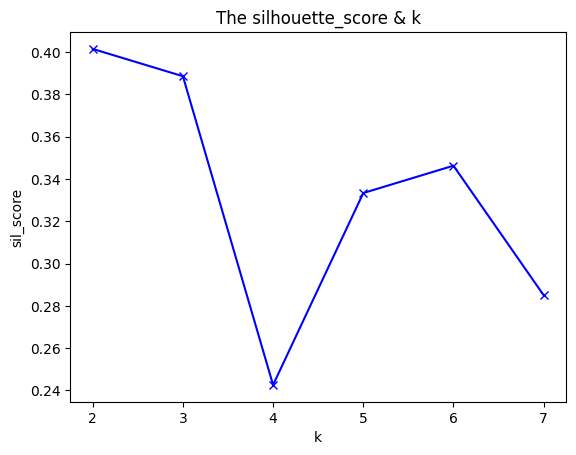

We have max silhouette score at k=  2


In [255]:
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt

scores = []
K = range(2,8)

for k in K:
    gmmModel = GaussianMixture(n_components=k)
    gmmModel.fit(X_train)
    scores.append(silhouette_score(X_train, gmmModel.predict(X_train)))

# Plot
plt.plot(K, scores, 'bx-')
plt.xlabel('k')
plt.ylabel('sil_score')
plt.title('The silhouette_score & k')
plt.show()

# Calculate k
id_max = np.argmax(scores)
print("We have max silhouette score at k= ", id_max + 2)

In [256]:
# select components = 2
from sklearn.mixture import GaussianMixture

gmmModel = GaussianMixture(n_components=2)
gmmModel.fit(X_train)



,"n_components n_components: int, default=1The number of mixture components.",2
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [257]:
# In các tham số
print(gmmModel.weights_)


[0.59440772 0.40559228]


In [258]:
print(gmmModel.means_)


[[2.15378953 2.30003646]
 [3.68246519 3.32281806]]


In [259]:
print(gmmModel.covariances_)

[[[1.19716918 0.68786163]
  [0.68786163 1.34626773]]

 [[1.28630398 0.77085089]
  [0.77085089 0.86983747]]]


In [260]:
types = gmmModel.predict(X_train)
print(type)

[1 1 0 1 0 0 1 0 0 0 1 1 0 0 0 1 1 1 1 0 1 0 0 1 1 1 0 1 0 1 0 0 1 1 1 1 1
 0 1 1 0 1 0 1 0 1 0 0 1 1 0 0 1 1 1 0 1 0 1 1 1 1 1 0 1 0 0 1 0 1 1 0 1 0
 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1 0 0 1
 1 1 1 0 0 1 1 0 0 0 1 0 0 1 0 1 0 1 1 0 0 0 1 0 1 1 0 1 1 1 1 1 1 1 0 0 1
 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 0 0 0 1 1 0 1 1 0 1]


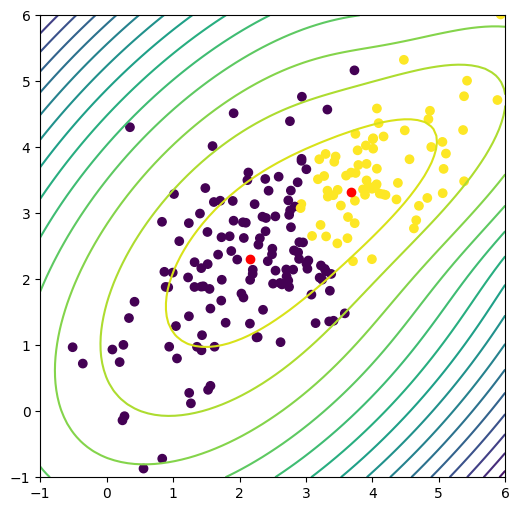

In [302]:

plt.figure(figsize=(6, 6))

X, Y = np.meshgrid(np.linspace(-1, 6, 70), np.linspace(-1, 6, 70))
XX = np.array([X.ravel(), Y.ravel()]).T 
Z = gmmModel.score_samples(XX)
Z = Z.reshape((70, 70))

plt.contour(X, Y, Z, levels=20)

plt.scatter(X_train[:, 0], X_train[:, 1], c=types) 
plt.scatter(gmmModel.means_[:, 0], gmmModel.means_[:, 1], color="red")

plt.xlim(-1, 6)
plt.ylim(-1, 6)

plt.show()